In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import io

# --- SECTION 1: THE MASTER DATASET ---
# verified: includes Olivia Rodrigo SOUR/GUTS and calculated SPT
csv_content = """artist,album,year,track_count,spotify_mau,hype_score,days_to_release,event_type,feature_track_count,first_week_streams,streams_per_track
Ed Sheeran,Divide,2017,16,120,9,21,0,0,375,23.44
Ed Sheeran,Equals,2021,14,365,8.5,21,0,0,270,19.29
Drake,Scorpion,2018,25,207,9,7,0,3,559,22.36
Drake,CLB,2021,21,365,9.5,14,0,12,512,24.38
Drake,FATD,2023,23,574,9,14,0,10,411,17.87
Travis Scott,ASTROWORLD,2018,17,207,9,14,0,11,350,20.59
Travis Scott,Utopia,2023,19,574,8,14,0,13,455,23.95
Eminem,TheDeathOfSlimShady,2024,19,640,9.0,45,0,7,382,20.11
The Weeknd,AfterHours,2020,14,299,9,21,0,0,450,32.14
The Weeknd,HUT,2024,22,640,10,21,0,6,580,26.36
Justin Bieber,Justice,2021,16,406,8,14,0,8,252,15.75
SZA,SOS,2022,23,489,9,21,0,4,400,17.39
Taylor Swift,Midnights,2022,20,489,10,21,0,1,776,38.80
Taylor Swift,1989TV,2023,21,574,9,21,0,0,600,28.57
Taylor Swift,TTPD,2024,31,640,10,28,0,2,1173,37.84
Taylor Swift,LifeOfAShowgirl,2025,12,680,10,45,0,1,920,76.66
Sabrina Carpenter,ShortNSweet,2024,12,640,8,21,0,0,450,37.50
Sabrina Carpenter,MansBestFriend,2025,13,715,9.5,30,0,0,610,46.92
Kendrick Lamar,MrMorale,2022,19,422,9.5,25,0,7,338,17.79
Kendrick Lamar,GNX,2024,12,640,10,7,1,7,363,30.25
Ariana Grande,EternalSunshine,2024,13,620,9,28,0,0,230,17.69
Olivia Rodrigo,SOUR,2021,11,365,9,28,0,0,385,35.00
Olivia Rodrigo,GUTS,2023,12,574,9,45,0,0,310,25.83"""

df = pd.read_csv(io.StringIO(csv_content))

# --- SECTION 2: MODEL TRAINING ---
features = ['year', 'track_count', 'spotify_mau', 'hype_score', 'days_to_release', 'event_type', 'feature_track_count']
X = df[features]
y = df['first_week_streams']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# --- SECTION 3: 2026 PROJECTIONS ---
market_mau = 751
proj_year = 2026

# Parameters: [year, tracks, mau, hype, days, event, feat_tracks]
d_params = [proj_year, 22, market_mau, 9.7, 14, 0, 2]
o_params = [proj_year, 12, market_mau, 9.5, 60, 0, 0]
a_params = [proj_year, 14, market_mau, 9.0, 28, 0, 1]

# Prediction Execution
d_pred = model.predict(pd.DataFrame([d_params], columns=features))[0]
o_pred = model.predict(pd.DataFrame([o_params], columns=features))[0]
a_pred = model.predict(pd.DataFrame([a_params], columns=features))[0]

print(f"\n🎧 2026 SUMMER BLOCKBUSTER PREDICTIONS")
print("="*80)
print(f"1. DRAKE - 'ICEMAN' (22 tracks | 2 w/ features):     {d_pred:,.0f} Million ( SPT: {d_pred/22:.2f}M)")
print(f"2. OLIVIA RODRIGO - 'OR3' (12 tracks | 0 w/ feat):    {o_pred:,.0f} Million ( SPT: {o_pred/12:.2f}M)")
print(f"3. ARIANA GRANDE - 'AG8' (14 tracks | 1 w/ feat):     {a_pred:,.0f} Million ( SPT: {a_pred/14:.2f}M)")
print("-" * 80)
print(f"Market Context: Year {proj_year} | {market_mau}M MAU")
print("="*80)

# Optional: Generate the CSV for download/push
df.to_csv('streaming_data_final.csv', index=False)


🎧 2026 SUMMER BLOCKBUSTER PREDICTIONS
1. DRAKE - 'ICEMAN' (22 tracks | 2 w/ features):     625 Million ( SPT: 28.40M)
2. OLIVIA RODRIGO - 'OR3' (12 tracks | 0 w/ feat):    651 Million ( SPT: 54.23M)
3. ARIANA GRANDE - 'AG8' (14 tracks | 1 w/ feat):     545 Million ( SPT: 38.93M)
--------------------------------------------------------------------------------
Market Context: Year 2026 | 751M MAU


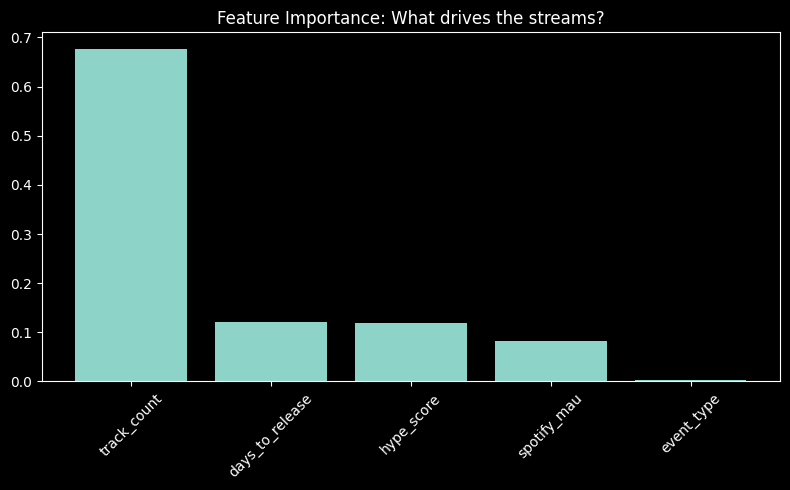

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get importance values from the trained model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the results
plt.figure(figsize=(8, 5))
plt.title("Feature Importance: What drives the streams?")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()